# 第8章: 統計的推定の基礎

## 学習目標
- 点推定量の性質（不偏性、一致性、有効性）を理解する
- 最尤推定法を理解し応用できる
- モーメント法による推定を理解する
- フィッシャー情報量とクラメール・ラオの下限を理解する
- 十分統計量の概念を理解する

## 📋 学習メタ情報

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

統計的推定は、標本データから母集団のパラメータを推測する手法です。点推定・区間推定の理論は、全ての統計分析の基礎となります。

### 実世界での応用

**世論調査**: 標本調査から母比率を推定し、信頼区間を計算

**品質管理**: 製品のサンプルから全体の不良率を推定

**臨床試験**: 治療効果の平均値を推定し、有効性を評価

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar, minimize
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 8.1 点推定量の基本概念

### 推定量と推定値
- **推定量** (Estimator): パラメータを推定する統計量（確率変数）
- **推定値** (Estimate): 実際のデータから計算された値

### 不偏性 (Unbiasedness)
推定量 $\hat{\theta}$ が不偏であるとは:
$$E[\hat{\theta}] = \theta$$

### バイアス
$$\text{Bias}(\hat{\theta}) = E[\hat{\theta}] - \theta$$

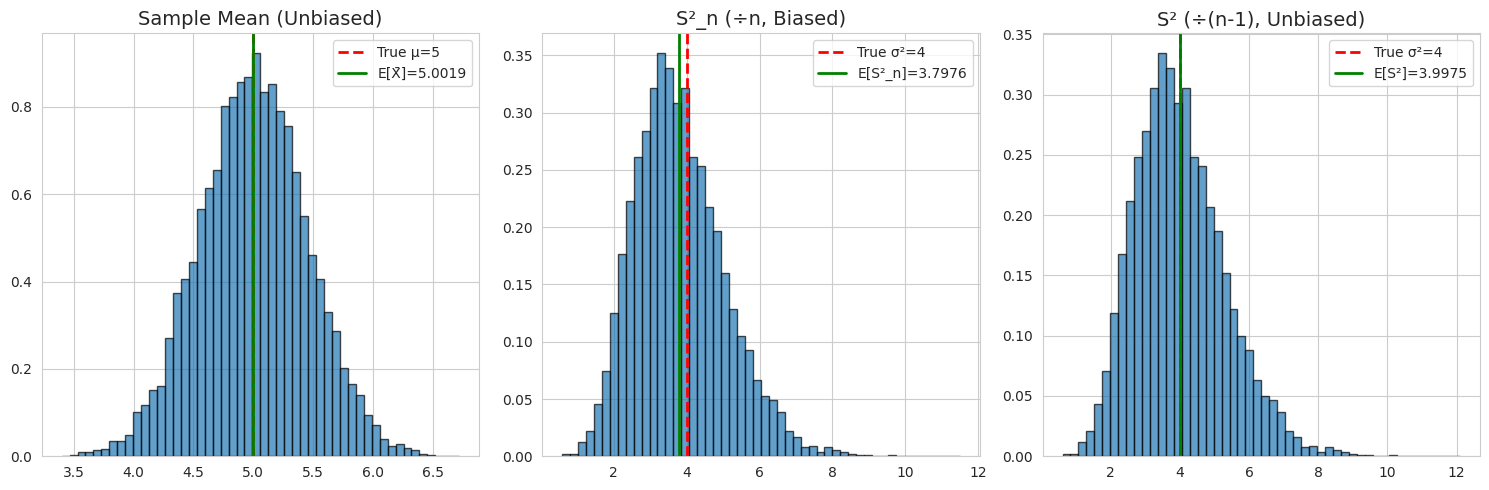

Bias of S²_n: -0.2024
Bias of S²:   -0.0025


In [2]:
# 不偏性の検証：標本平均 vs 標本分散
n_simulations = 10000
n = 20  # Sample size
true_mu = 5
true_sigma = 2

# Generate samples
samples = np.random.normal(true_mu, true_sigma, (n_simulations, n))

# Sample mean (unbiased for mu)
sample_means = np.mean(samples, axis=1)

# Sample variance with different denominators
sample_var_n = np.var(samples, axis=1, ddof=0)  # Divide by n (biased)
sample_var_n1 = np.var(samples, axis=1, ddof=1)  # Divide by n-1 (unbiased)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sample mean distribution
axes[0].hist(sample_means, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[0].axvline(true_mu, color='r', linestyle='--', linewidth=2, label=f'True μ={true_mu}')
axes[0].axvline(np.mean(sample_means), color='g', linestyle='-', linewidth=2, 
                label=f'E[X̄]={np.mean(sample_means):.4f}')
axes[0].set_title('Sample Mean (Unbiased)', fontsize=14)
axes[0].legend()

# Biased variance estimator
axes[1].hist(sample_var_n, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[1].axvline(true_sigma**2, color='r', linestyle='--', linewidth=2, 
                label=f'True σ²={true_sigma**2}')
axes[1].axvline(np.mean(sample_var_n), color='g', linestyle='-', linewidth=2, 
                label=f'E[S²_n]={np.mean(sample_var_n):.4f}')
axes[1].set_title('S²_n (÷n, Biased)', fontsize=14)
axes[1].legend()

# Unbiased variance estimator
axes[2].hist(sample_var_n1, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[2].axvline(true_sigma**2, color='r', linestyle='--', linewidth=2, 
                label=f'True σ²={true_sigma**2}')
axes[2].axvline(np.mean(sample_var_n1), color='g', linestyle='-', linewidth=2, 
                label=f'E[S²]={np.mean(sample_var_n1):.4f}')
axes[2].set_title('S² (÷(n-1), Unbiased)', fontsize=14)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Bias of S²_n: {np.mean(sample_var_n) - true_sigma**2:.4f}")
print(f"Bias of S²:   {np.mean(sample_var_n1) - true_sigma**2:.4f}")

## 8.2 一致性 (Consistency)

### 弱一致性
推定量 $\hat{\theta}_n$ が一致推定量であるとは:
$$\hat{\theta}_n \xrightarrow{p} \theta \text{ as } n \to \infty$$

### 十分条件
以下の条件を満たせば一致推定量:
1. $\lim_{n \to \infty} E[\hat{\theta}_n] = \theta$
2. $\lim_{n \to \infty} \text{Var}(\hat{\theta}_n) = 0$

/tmp/ipykernel_14004/3261338609.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(mean_estimates, labels=sample_sizes)
/tmp/ipykernel_14004/3261338609.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(var_estimates, labels=sample_sizes)


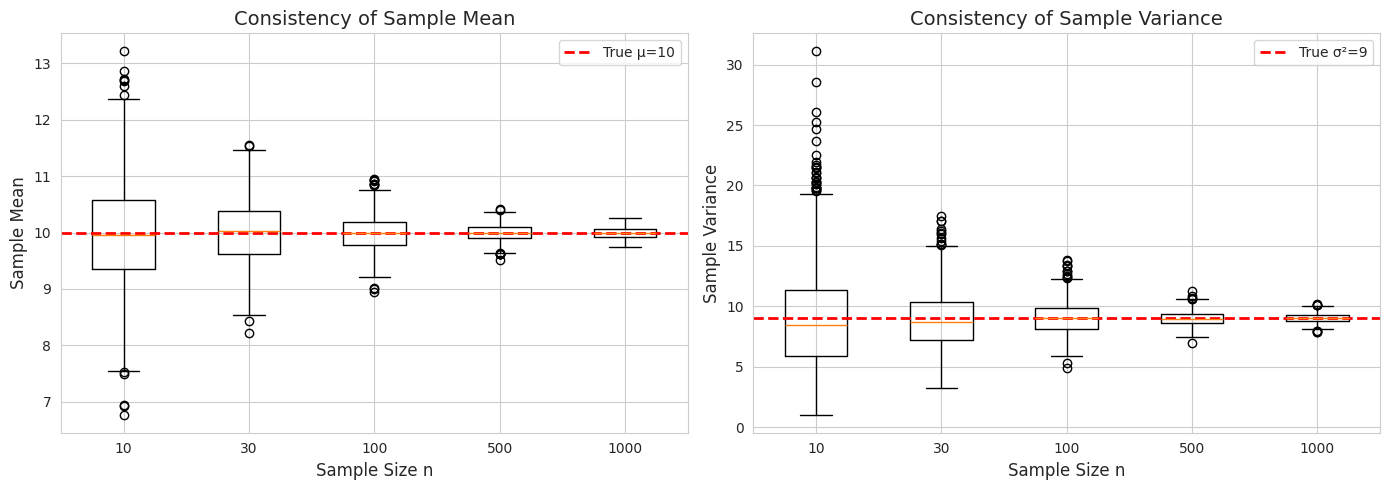

In [3]:
# 一致性の可視化
n_simulations = 1000
sample_sizes = [10, 30, 100, 500, 1000]
true_mu = 10
true_sigma = 3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Consistency of sample mean
mean_estimates = []
var_estimates = []

for n in sample_sizes:
    samples = np.random.normal(true_mu, true_sigma, (n_simulations, n))
    means = np.mean(samples, axis=1)
    mean_estimates.append(means)
    var_estimates.append(np.var(samples, axis=1, ddof=1))

axes[0].boxplot(mean_estimates, labels=sample_sizes)
axes[0].axhline(true_mu, color='r', linestyle='--', linewidth=2, label=f'True μ={true_mu}')
axes[0].set_xlabel('Sample Size n', fontsize=12)
axes[0].set_ylabel('Sample Mean', fontsize=12)
axes[0].set_title('Consistency of Sample Mean', fontsize=14)
axes[0].legend()

axes[1].boxplot(var_estimates, labels=sample_sizes)
axes[1].axhline(true_sigma**2, color='r', linestyle='--', linewidth=2, 
                label=f'True σ²={true_sigma**2}')
axes[1].set_xlabel('Sample Size n', fontsize=12)
axes[1].set_ylabel('Sample Variance', fontsize=12)
axes[1].set_title('Consistency of Sample Variance', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 8.3 有効性 (Efficiency)

### 平均二乗誤差 (MSE)
$$\text{MSE}(\hat{\theta}) = E[(\hat{\theta} - \theta)^2] = \text{Var}(\hat{\theta}) + [\text{Bias}(\hat{\theta})]^2$$

### 相対効率
推定量 $\hat{\theta}_1$ と $\hat{\theta}_2$ の相対効率:
$$e(\hat{\theta}_1, \hat{\theta}_2) = \frac{\text{Var}(\hat{\theta}_2)}{\text{Var}(\hat{\theta}_1)}$$

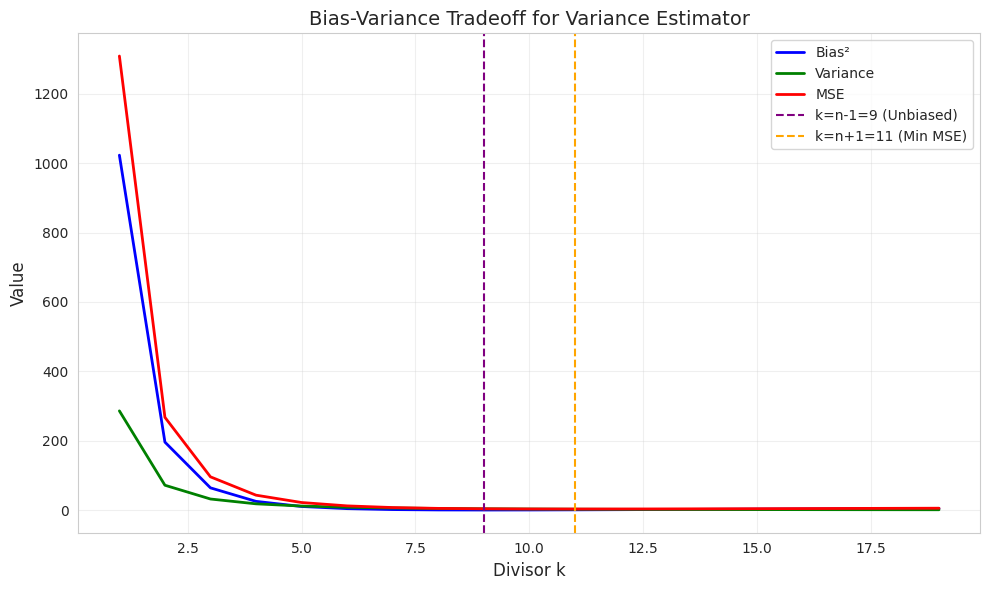

Minimum MSE at k = 11
Theoretical minimum MSE is at k = n+1 = 11


In [4]:
# MSEとバイアス・分散のトレードオフ
n_simulations = 10000
n = 10
true_sigma2 = 4

# Normal distribution with known mean=0
samples = np.random.normal(0, np.sqrt(true_sigma2), (n_simulations, n))

# Different estimators for variance
# S²_k = (1/k) * Σ(Xi - X̄)²
sum_sq = np.sum((samples - np.mean(samples, axis=1, keepdims=True))**2, axis=1)

k_values = np.arange(1, 2*n)
bias_sq = []
variance = []
mse = []

for k in k_values:
    estimator = sum_sq / k
    bias = np.mean(estimator) - true_sigma2
    var = np.var(estimator)
    bias_sq.append(bias**2)
    variance.append(var)
    mse.append(var + bias**2)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_values, bias_sq, 'b-', linewidth=2, label='Bias²')
ax.plot(k_values, variance, 'g-', linewidth=2, label='Variance')
ax.plot(k_values, mse, 'r-', linewidth=2, label='MSE')
ax.axvline(n-1, color='purple', linestyle='--', label=f'k=n-1={n-1} (Unbiased)')
ax.axvline(n+1, color='orange', linestyle='--', label=f'k=n+1={n+1} (Min MSE)')

ax.set_xlabel('Divisor k', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Bias-Variance Tradeoff for Variance Estimator', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Minimum MSE at k = {k_values[np.argmin(mse)]}")
print(f"Theoretical minimum MSE is at k = n+1 = {n+1}")

## 8.4 最尤推定法 (Maximum Likelihood Estimation)

### 尤度関数
データ $x_1, ..., x_n$ が与えられたとき:
$$L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)$$

### 対数尤度関数
$$\ell(\theta) = \log L(\theta) = \sum_{i=1}^{n} \log f(x_i; \theta)$$

### 最尤推定量 (MLE)
$$\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} L(\theta) = \arg\max_{\theta} \ell(\theta)$$

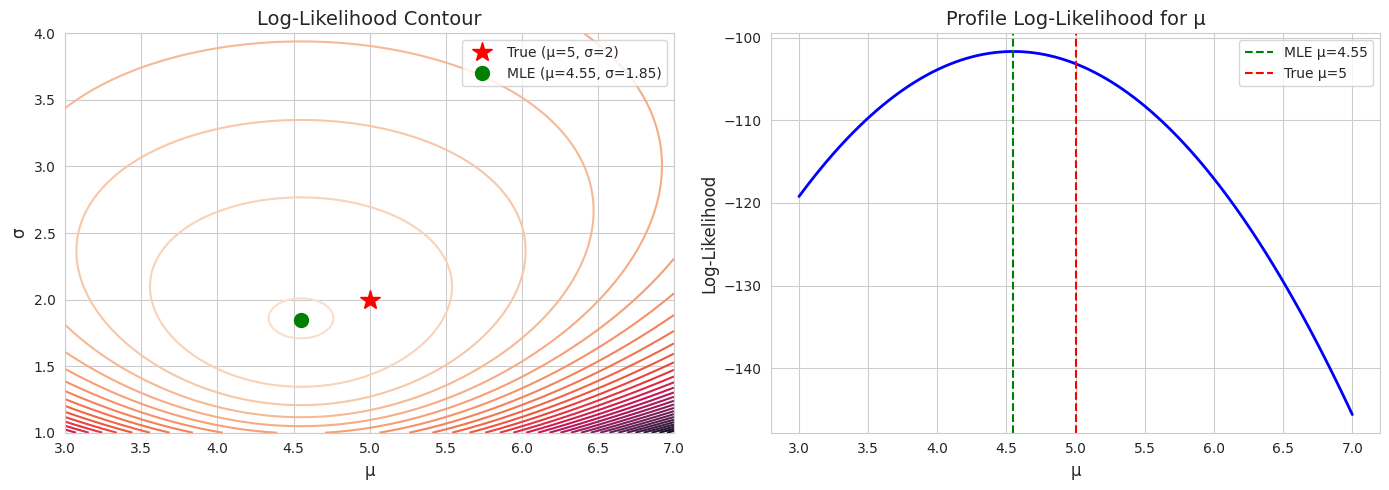

Analytical MLE: μ = 4.5491, σ = 1.8486
Numerical MLE:  μ = 4.5491, σ = 1.8486


In [5]:
# MLEの例：正規分布のパラメータ推定
np.random.seed(42)
n = 50
true_mu = 5
true_sigma = 2

data = np.random.normal(true_mu, true_sigma, n)

# Log-likelihood function
def neg_log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    n = len(data)
    ll = -n/2 * np.log(2*np.pi) - n*np.log(sigma) - np.sum((data - mu)**2) / (2*sigma**2)
    return -ll  # Minimize negative log-likelihood

# Grid search for visualization
mu_range = np.linspace(3, 7, 100)
sigma_range = np.linspace(1, 4, 100)
MU, SIGMA = np.meshgrid(mu_range, sigma_range)
LL = np.zeros_like(MU)

for i in range(len(sigma_range)):
    for j in range(len(mu_range)):
        LL[i, j] = -neg_log_likelihood([mu_range[j], sigma_range[i]], data)

# Find MLE
result = minimize(neg_log_likelihood, [0, 1], args=(data,), method='L-BFGS-B',
                  bounds=[(None, None), (0.01, None)])
mle_mu, mle_sigma = result.x

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contour plot
contour = axes[0].contour(MU, SIGMA, LL, levels=30)
axes[0].plot(true_mu, true_sigma, 'r*', markersize=15, label=f'True (μ={true_mu}, σ={true_sigma})')
axes[0].plot(mle_mu, mle_sigma, 'go', markersize=10, 
             label=f'MLE (μ={mle_mu:.2f}, σ={mle_sigma:.2f})')
axes[0].set_xlabel('μ', fontsize=12)
axes[0].set_ylabel('σ', fontsize=12)
axes[0].set_title('Log-Likelihood Contour', fontsize=14)
axes[0].legend()

# Profile likelihood for mu
ll_mu = []
for mu in mu_range:
    ll_mu.append(-neg_log_likelihood([mu, mle_sigma], data))

axes[1].plot(mu_range, ll_mu, 'b-', linewidth=2)
axes[1].axvline(mle_mu, color='g', linestyle='--', label=f'MLE μ={mle_mu:.2f}')
axes[1].axvline(true_mu, color='r', linestyle='--', label=f'True μ={true_mu}')
axes[1].set_xlabel('μ', fontsize=12)
axes[1].set_ylabel('Log-Likelihood', fontsize=12)
axes[1].set_title('Profile Log-Likelihood for μ', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

# Analytical MLE
print(f"Analytical MLE: μ = {np.mean(data):.4f}, σ = {np.std(data):.4f}")
print(f"Numerical MLE:  μ = {mle_mu:.4f}, σ = {mle_sigma:.4f}")

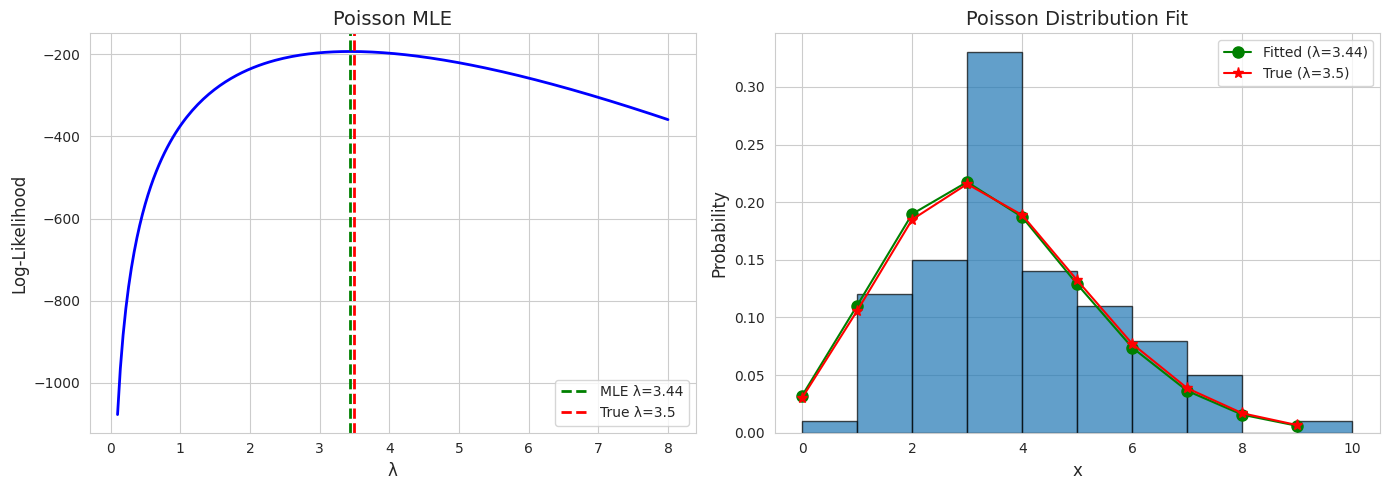

In [6]:
# MLEの例：ポアソン分布
np.random.seed(123)
n = 100
true_lambda = 3.5

data = np.random.poisson(true_lambda, n)

# Log-likelihood for Poisson
lambda_range = np.linspace(0.1, 8, 200)
log_likelihood = []

for lam in lambda_range:
    ll = np.sum(data * np.log(lam) - lam - np.array([np.sum(np.log(np.arange(1, x+1))) for x in data]))
    log_likelihood.append(ll)

# MLE for Poisson is sample mean
mle_lambda = np.mean(data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-likelihood plot
axes[0].plot(lambda_range, log_likelihood, 'b-', linewidth=2)
axes[0].axvline(mle_lambda, color='g', linestyle='--', linewidth=2, 
                label=f'MLE λ={mle_lambda:.2f}')
axes[0].axvline(true_lambda, color='r', linestyle='--', linewidth=2, 
                label=f'True λ={true_lambda}')
axes[0].set_xlabel('λ', fontsize=12)
axes[0].set_ylabel('Log-Likelihood', fontsize=12)
axes[0].set_title('Poisson MLE', fontsize=14)
axes[0].legend()

# Data histogram
axes[1].hist(data, bins=range(0, max(data)+2), density=True, alpha=0.7, edgecolor='black')
x = np.arange(0, max(data)+1)
axes[1].plot(x, stats.poisson.pmf(x, mle_lambda), 'go-', markersize=8, label=f'Fitted (λ={mle_lambda:.2f})')
axes[1].plot(x, stats.poisson.pmf(x, true_lambda), 'r*-', markersize=8, label=f'True (λ={true_lambda})')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_title('Poisson Distribution Fit', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 8.5 モーメント法 (Method of Moments)

### 基本概念
母集団モーメントを標本モーメントで置き換えて推定:
$$E[X^k] = \frac{1}{n}\sum_{i=1}^{n} X_i^k$$

### 手順
1. 母集団モーメントをパラメータの関数として表す
2. 母集団モーメントを標本モーメントで置き換える
3. パラメータについて解く

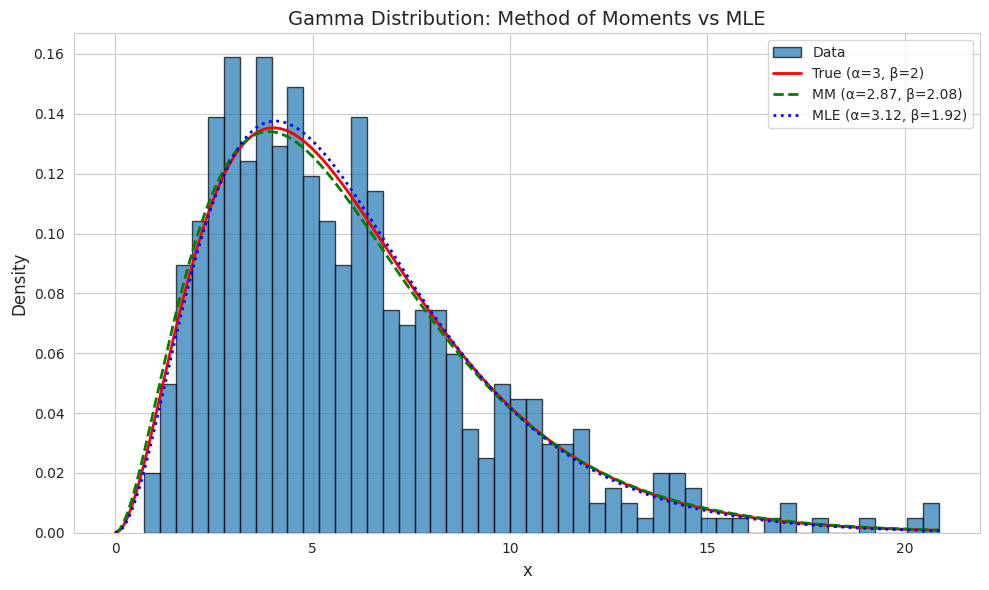

In [7]:
# モーメント法の例：ガンマ分布
np.random.seed(456)
n = 500
true_alpha = 3
true_beta = 2  # scale parameter

data = np.random.gamma(true_alpha, true_beta, n)

# Method of moments for Gamma(alpha, beta)
# E[X] = alpha * beta
# E[X²] = alpha * beta² + (alpha * beta)²
# Var(X) = alpha * beta²

sample_mean = np.mean(data)
sample_var = np.var(data, ddof=1)

# Solve: mean = alpha * beta, var = alpha * beta²
# beta = var / mean, alpha = mean² / var
mm_beta = sample_var / sample_mean
mm_alpha = sample_mean**2 / sample_var

# MLE for comparison
def neg_ll_gamma(params, data):
    alpha, beta = params
    if alpha <= 0 or beta <= 0:
        return np.inf
    return -np.sum(stats.gamma.logpdf(data, alpha, scale=beta))

result = minimize(neg_ll_gamma, [mm_alpha, mm_beta], args=(data,), method='L-BFGS-B',
                  bounds=[(0.01, None), (0.01, None)])
mle_alpha, mle_beta = result.x

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
ax.hist(data, bins=50, density=True, alpha=0.7, edgecolor='black', label='Data')

# Fitted distributions
x = np.linspace(0, max(data), 200)
ax.plot(x, stats.gamma.pdf(x, true_alpha, scale=true_beta), 'r-', linewidth=2,
        label=f'True (α={true_alpha}, β={true_beta})')
ax.plot(x, stats.gamma.pdf(x, mm_alpha, scale=mm_beta), 'g--', linewidth=2,
        label=f'MM (α={mm_alpha:.2f}, β={mm_beta:.2f})')
ax.plot(x, stats.gamma.pdf(x, mle_alpha, scale=mle_beta), 'b:', linewidth=2,
        label=f'MLE (α={mle_alpha:.2f}, β={mle_beta:.2f})')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Gamma Distribution: Method of Moments vs MLE', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 8.6 フィッシャー情報量とクラメール・ラオの下限

### フィッシャー情報量
$$I(\theta) = E\left[\left(\frac{\partial \log f(X; \theta)}{\partial \theta}\right)^2\right] = -E\left[\frac{\partial^2 \log f(X; \theta)}{\partial \theta^2}\right]$$

### クラメール・ラオの下限
任意の不偏推定量 $\hat{\theta}$ について:
$$\text{Var}(\hat{\theta}) \geq \frac{1}{nI(\theta)}$$

### 有効推定量
下限を達成する推定量を有効推定量という。

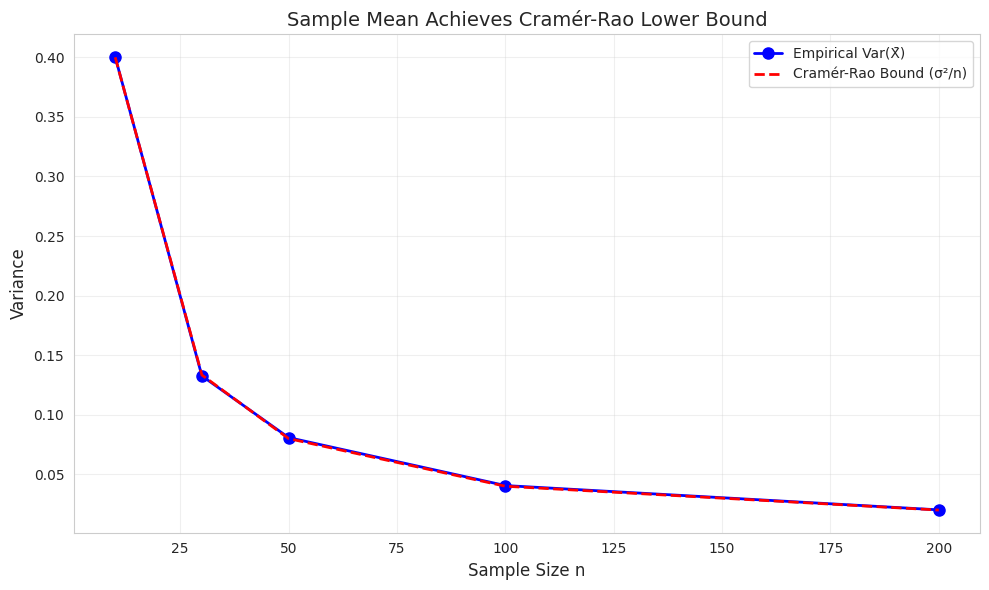

Sample mean is an efficient estimator for μ!


In [8]:
# クラメール・ラオの下限の検証
# 正規分布 N(μ, σ²) における μ の推定
# Fisher information for μ: I(μ) = 1/σ²
# CR lower bound: 1/(n * I(μ)) = σ²/n

n_simulations = 10000
sample_sizes = [10, 30, 50, 100, 200]
true_sigma = 2

variances = []
cr_bounds = []

for n in sample_sizes:
    samples = np.random.normal(0, true_sigma, (n_simulations, n))
    sample_means = np.mean(samples, axis=1)
    variances.append(np.var(sample_means))
    cr_bounds.append(true_sigma**2 / n)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sample_sizes, variances, 'bo-', markersize=8, linewidth=2, label='Empirical Var(X̄)')
ax.plot(sample_sizes, cr_bounds, 'r--', linewidth=2, label='Cramér-Rao Bound (σ²/n)')

ax.set_xlabel('Sample Size n', fontsize=12)
ax.set_ylabel('Variance', fontsize=12)
ax.set_title('Sample Mean Achieves Cramér-Rao Lower Bound', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Sample mean is an efficient estimator for μ!")

In [9]:
# フィッシャー情報量の計算例
print("フィッシャー情報量の例")
print("="*50)

print("\n1. 正規分布 N(μ, σ²)")
print("   I(μ) = 1/σ² (σ既知)")
print("   I(σ²) = 1/(2σ⁴) (μ既知)")

print("\n2. ポアソン分布 Poi(λ)")
print("   I(λ) = 1/λ")

print("\n3. 指数分布 Exp(λ)")
print("   I(λ) = 1/λ²")

print("\n4. ベルヌーイ分布 Ber(p)")
print("   I(p) = 1/(p(1-p))")

フィッシャー情報量の例

1. 正規分布 N(μ, σ²)
   I(μ) = 1/σ² (σ既知)
   I(σ²) = 1/(2σ⁴) (μ既知)

2. ポアソン分布 Poi(λ)
   I(λ) = 1/λ

3. 指数分布 Exp(λ)
   I(λ) = 1/λ²

4. ベルヌーイ分布 Ber(p)
   I(p) = 1/(p(1-p))


## 8.7 十分統計量 (Sufficient Statistics)

### 定義
統計量 $T(X)$ がパラメータ $\theta$ に対して十分であるとは、$T(X)$ が与えられたときの条件付き分布が $\theta$ に依存しないこと。

### 因子分解定理（ネイマン・フィッシャー）
$T(X)$ が十分統計量であるための必要十分条件:
$$f(x; \theta) = g(T(x), \theta) \cdot h(x)$$

In [10]:
# 十分統計量の例
print("十分統計量の例")
print("="*50)

print("\n1. 正規分布 N(μ, σ²)")
print("   μの十分統計量: ΣXi（または X̄）")
print("   (μ, σ²)の十分統計量: (ΣXi, ΣXi²)")

print("\n2. ポアソン分布 Poi(λ)")
print("   十分統計量: ΣXi")

print("\n3. 指数分布 Exp(λ)")
print("   十分統計量: ΣXi")

print("\n4. 一様分布 U(0, θ)")
print("   十分統計量: max(Xi)")

十分統計量の例

1. 正規分布 N(μ, σ²)
   μの十分統計量: ΣXi（または X̄）
   (μ, σ²)の十分統計量: (ΣXi, ΣXi²)

2. ポアソン分布 Poi(λ)
   十分統計量: ΣXi

3. 指数分布 Exp(λ)
   十分統計量: ΣXi

4. 一様分布 U(0, θ)
   十分統計量: max(Xi)


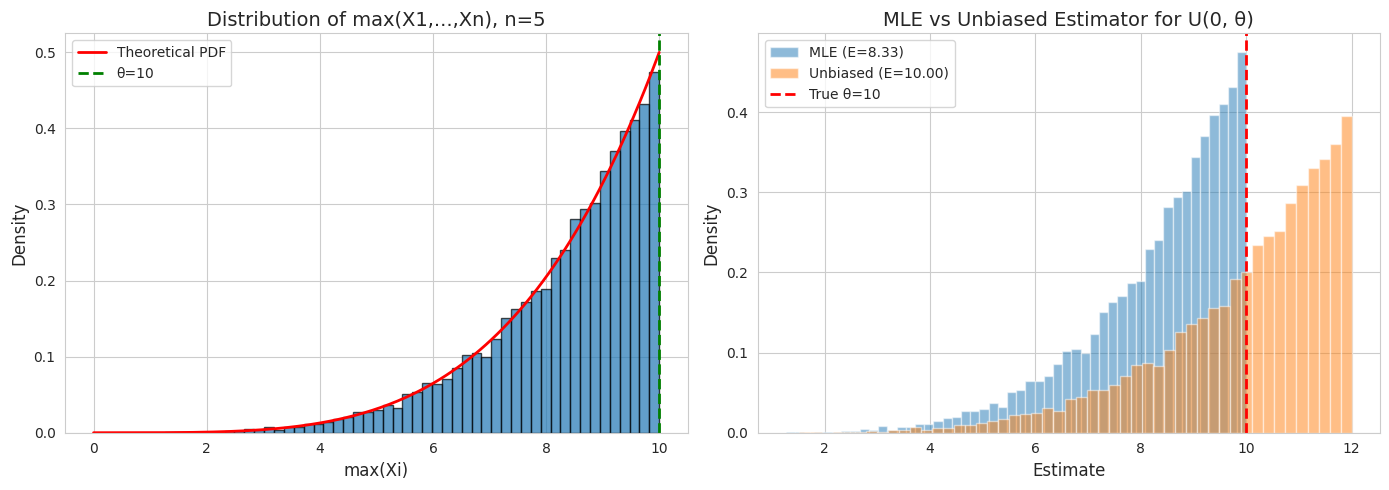

MLE bias: -1.6679
Unbiased estimator bias: -0.0015


In [11]:
# 十分統計量の可視化：一様分布の最大値
np.random.seed(789)
n_simulations = 10000
n = 5
true_theta = 10

# Sufficient statistic: max(X1, ..., Xn)
samples = np.random.uniform(0, true_theta, (n_simulations, n))
max_values = np.max(samples, axis=1)

# Distribution of max: F(x) = (x/θ)^n for 0 ≤ x ≤ θ
# f(x) = n * x^(n-1) / θ^n

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of max values
axes[0].hist(max_values, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(0, true_theta, 200)
pdf = n * x**(n-1) / true_theta**n
axes[0].plot(x, pdf, 'r-', linewidth=2, label=f'Theoretical PDF')
axes[0].axvline(true_theta, color='g', linestyle='--', linewidth=2, label=f'θ={true_theta}')
axes[0].set_xlabel('max(Xi)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(f'Distribution of max(X1,...,Xn), n={n}', fontsize=14)
axes[0].legend()

# Different estimators using sufficient statistic
# MLE: θ̂_MLE = max(Xi) - biased
# Unbiased: θ̂ = (n+1)/n * max(Xi)
mle_estimates = max_values
unbiased_estimates = (n + 1) / n * max_values

axes[1].hist(mle_estimates, bins=50, alpha=0.5, density=True, label=f'MLE (E={np.mean(mle_estimates):.2f})')
axes[1].hist(unbiased_estimates, bins=50, alpha=0.5, density=True, 
             label=f'Unbiased (E={np.mean(unbiased_estimates):.2f})')
axes[1].axvline(true_theta, color='r', linestyle='--', linewidth=2, label=f'True θ={true_theta}')
axes[1].set_xlabel('Estimate', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('MLE vs Unbiased Estimator for U(0, θ)', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"MLE bias: {np.mean(mle_estimates) - true_theta:.4f}")
print(f"Unbiased estimator bias: {np.mean(unbiased_estimates) - true_theta:.4f}")

## 8.8 MLEの漸近的性質

### 一致性
$$\hat{\theta}_{\text{MLE}} \xrightarrow{p} \theta_0$$

### 漸近正規性
$$\sqrt{n}(\hat{\theta}_{\text{MLE}} - \theta_0) \xrightarrow{d} N(0, I(\theta_0)^{-1})$$

### 漸近有効性
MLEは漸近的にクラメール・ラオの下限を達成する。

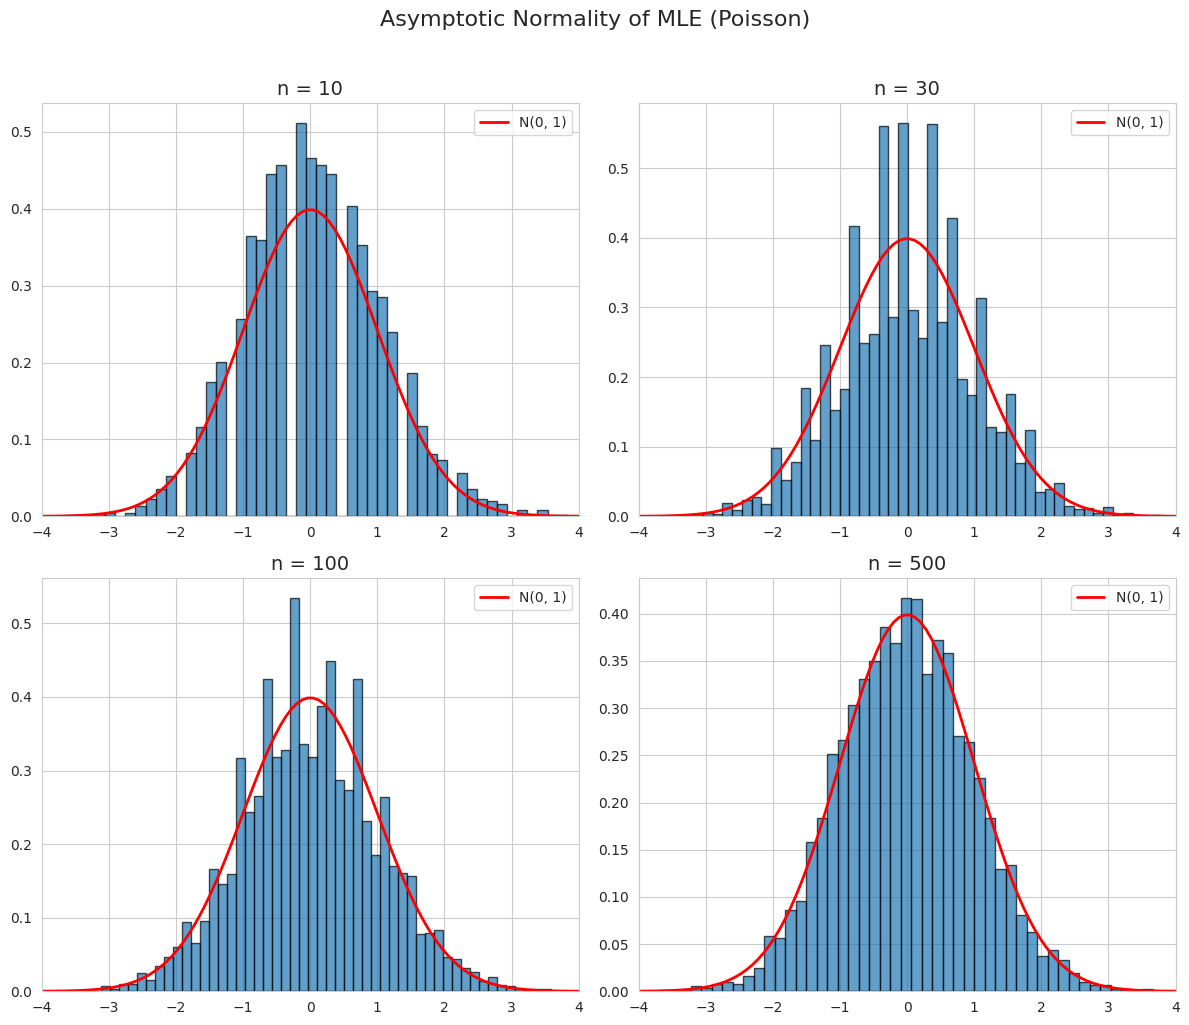

In [12]:
# MLEの漸近正規性の検証
n_simulations = 5000
true_lambda = 3

sample_sizes = [10, 30, 100, 500]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, n in enumerate(sample_sizes):
    row, col = idx // 2, idx % 2
    
    # Generate Poisson samples
    samples = np.random.poisson(true_lambda, (n_simulations, n))
    mle_estimates = np.mean(samples, axis=1)  # MLE for Poisson
    
    # Standardize using asymptotic variance
    # For Poisson: I(λ) = 1/λ, so asymptotic variance = λ/n
    standardized = np.sqrt(n) * (mle_estimates - true_lambda) / np.sqrt(true_lambda)
    
    axes[row, col].hist(standardized, bins=50, density=True, alpha=0.7, edgecolor='black')
    x = np.linspace(-4, 4, 100)
    axes[row, col].plot(x, stats.norm.pdf(x), 'r-', linewidth=2, label='N(0, 1)')
    axes[row, col].set_title(f'n = {n}', fontsize=14)
    axes[row, col].set_xlim(-4, 4)
    axes[row, col].legend()

plt.suptitle('Asymptotic Normality of MLE (Poisson)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8.9 練習問題

### 問題1
指数分布 $Exp(\lambda)$ からの標本 $X_1, ..., X_n$ について、$\lambda$ の最尤推定量を求めよ。また、この推定量が不偏かどうか調べよ。

### 問題2
$X_1, ..., X_n \sim N(\mu, \sigma^2)$ のとき、$(\mu, \sigma^2)$ の最尤推定量を求め、それぞれの不偏性を調べよ。

### 問題3
一様分布 $U(0, \theta)$ からの標本で、$\theta$ のMLEと不偏推定量を求め、それぞれのMSEを比較せよ。

In [13]:
# 問題1の解答
print("問題1: 指数分布のMLE")
print("="*50)
print("\n尤度関数: L(λ) = λⁿ exp(-λΣXi)")
print("対数尤度: ℓ(λ) = n log λ - λΣXi")
print("\n∂ℓ/∂λ = n/λ - ΣXi = 0")
print("∴ λ̂_MLE = n/ΣXi = 1/X̄")
print("\n不偏性の検証:")
print("E[1/X̄] ≠ 1/E[X̄] = λ（イェンセンの不等式より）")
print("よって、MLEは不偏ではない")

# Simulation verification
n = 20
true_lambda = 2
n_simulations = 10000

samples = np.random.exponential(1/true_lambda, (n_simulations, n))
mle_estimates = 1 / np.mean(samples, axis=1)

print(f"\nシミュレーション検証 (n={n}, λ={true_lambda}):")
print(f"E[λ̂_MLE] = {np.mean(mle_estimates):.4f}")
print(f"Bias = {np.mean(mle_estimates) - true_lambda:.4f}")

問題1: 指数分布のMLE

尤度関数: L(λ) = λⁿ exp(-λΣXi)
対数尤度: ℓ(λ) = n log λ - λΣXi

∂ℓ/∂λ = n/λ - ΣXi = 0
∴ λ̂_MLE = n/ΣXi = 1/X̄

不偏性の検証:
E[1/X̄] ≠ 1/E[X̄] = λ（イェンセンの不等式より）
よって、MLEは不偏ではない

シミュレーション検証 (n=20, λ=2):
E[λ̂_MLE] = 2.1090
Bias = 0.1090


In [14]:
# 問題2の解答
print("問題2: 正規分布のMLE")
print("="*50)
print("\nMLEの導出:")
print("μ̂_MLE = X̄ (不偏)")
print("σ̂²_MLE = (1/n)Σ(Xi - X̄)² (偏りあり)")
print("\n不偏性:")
print("E[μ̂_MLE] = μ ✓")
print("E[σ̂²_MLE] = ((n-1)/n)σ² ≠ σ² ✗")
print("\n不偏推定量: S² = (1/(n-1))Σ(Xi - X̄)²")

問題2: 正規分布のMLE

MLEの導出:
μ̂_MLE = X̄ (不偏)
σ̂²_MLE = (1/n)Σ(Xi - X̄)² (偏りあり)

不偏性:
E[μ̂_MLE] = μ ✓
E[σ̂²_MLE] = ((n-1)/n)σ² ≠ σ² ✗

不偏推定量: S² = (1/(n-1))Σ(Xi - X̄)²


In [15]:
# 問題3の解答
print("問題3: 一様分布 U(0, θ) の推定量比較")
print("="*50)

n_simulations = 10000
n = 10
true_theta = 5

samples = np.random.uniform(0, true_theta, (n_simulations, n))
max_values = np.max(samples, axis=1)

# MLE
mle = max_values
mle_bias = np.mean(mle) - true_theta
mle_var = np.var(mle)
mle_mse = mle_var + mle_bias**2

# Unbiased estimator
unbiased = (n + 1) / n * max_values
unbiased_bias = np.mean(unbiased) - true_theta
unbiased_var = np.var(unbiased)
unbiased_mse = unbiased_var + unbiased_bias**2

print(f"\nサンプルサイズ n = {n}, 真値 θ = {true_theta}")
print("\nMLE (θ̂ = max(Xi)):")
print(f"  Bias = {mle_bias:.4f}")
print(f"  Variance = {mle_var:.4f}")
print(f"  MSE = {mle_mse:.4f}")

print("\n不偏推定量 (θ̂ = (n+1)/n * max(Xi)):")
print(f"  Bias = {unbiased_bias:.4f}")
print(f"  Variance = {unbiased_var:.4f}")
print(f"  MSE = {unbiased_mse:.4f}")

print(f"\n理論値:")
print(f"  MLE MSE = 2θ²/((n+1)(n+2)) = {2*true_theta**2/((n+1)*(n+2)):.4f}")
print(f"  Unbiased MSE = θ²/(n(n+2)) = {true_theta**2/(n*(n+2)):.4f}")

問題3: 一様分布 U(0, θ) の推定量比較

サンプルサイズ n = 10, 真値 θ = 5

MLE (θ̂ = max(Xi)):
  Bias = -0.4608
  Variance = 0.1772
  MSE = 0.3896

不偏推定量 (θ̂ = (n+1)/n * max(Xi)):
  Bias = -0.0069
  Variance = 0.2145
  MSE = 0.2145

理論値:
  MLE MSE = 2θ²/((n+1)(n+2)) = 0.3788
  Unbiased MSE = θ²/(n(n+2)) = 0.2083


## ⚠️ よくある間違いと解決策

### ❌ 点推定と区間推定の混同
**正しい理解:** 点推定は1つの値、区間推定は範囲
**解決策:** 信頼区間は「母数が含まれる確率95%の区間」

### ❌ 不偏性と一致性の混同
**正しい理解:** 不偏性はE[θ̂]=θ、一致性はn→∞でθ̂→θ
**解決策:** 不偏でも一致しない推定量も存在

---

## 📝 理解度チェッククイズ

### 問題 1
最尤推定量の定義を述べよ

### 問題 2
不偏推定量とは何か？なぜ重要か？

---

## 📚 まとめ

お疲れ様でした！この章の内容は統計的推論の核心部分です。

---